# Topic Modeling Tool

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/topic-modeler/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/topic-modeler/demo.ipynb)

> "What are these documents about?" — discover the themes in a pile of text automatically, no labels required.

You have 10,000 support tickets / reviews / articles and no idea what's in them. Topic modeling finds
the recurring themes unsupervised - clusters of words that co-occur - and tags each document. This
build uses **NMF over TF-IDF**, which separates short texts far better than classic LDA.

**What this notebook covers**
1. Fitting topics with NMF over TF-IDF
2. Reading the top words per topic
3. Labeling each document with its dominant topic
4. Why NMF beats LDA on short docs
5. Topic sizes, visualized


## Step 1 - Fit topics, unsupervised

21 short documents, no labels. NMF factorizes the TF-IDF matrix into topics × words and docs ×
topics. The top words of each topic read as a theme.

In [1]:
from topics import fit_topics, topic_sizes, label_documents, SAMPLE_DOCS

model = fit_topics(SAMPLE_DOCS, n_topics=3)
for t in model.topics:
    print(f"Topic {t.id}: {', '.join(t.top_words)}")


Topic 0: training, neural, network, added, regularization, dropout, overfit, data
Topic 1: team, win, final, scored, minute, game, championship, fans
Topic 2: model, language, researchers, answering, question, medical, fine, tuned


## Step 2 - Tag every document

The practical payoff: each doc gets its dominant topic and a confidence. Now those 21 docs are
sortable, filterable, and countable by theme.

In [2]:
for r in label_documents(model, SAMPLE_DOCS):
    print(f"  T{r['topic']} ({r['confidence']:.2f})  {r['doc']}")


  T0 (0.57)  The new GPU delivers massive speedups for training deep neur...
  T2 (0.69)  Our model reached state of the art accuracy on the image cla...
  T2 (0.45)  Transformers and attention mechanisms power modern natural l...
  T2 (0.84)  Researchers fine-tuned a large language model for medical qu...
  T0 (0.58)  The neural network overfit the training data so we added dro...
  T2 (0.69)  Gradient descent optimizes the model weights to minimize the...
  T0 (0.46)  The dataset was labeled and split into training and validati...
  T2 (0.00)  The central bank raised interest rates to combat rising infl...
  T1 (0.07)  Stock markets fell as bond yields climbed and the dollar str...
  T1 (0.02)  Investors worry about a recession as GDP growth slows and un...
  T2 (0.00)  Quarterly earnings beat expectations, sending the company's ...
  T1 (0.14)  The hedge fund shorted the stock ahead of the disappointing ...
  T1 (0.04)  Bond prices rose as investors sought safe assets amid market...

## Step 3 - Why NMF, not LDA?

LDA's generative bag-of-words model assumes long documents; on short texts (tickets, tweets,
headlines) its topics come out muddled. NMF on TF-IDF is deterministic and produces crisper,
more separable topics for exactly this short-text case - which is why it's the choice here.

In [3]:
from collections import Counter
dom = [model.dominant_topic(i) for i in range(len(SAMPLE_DOCS))]
# the sample is 3 themes of 7 docs each (roughly ML, finance, sports)
for name, seg in [("docs 1-7", dom[:7]), ("docs 8-14", dom[7:14]), ("docs 15-21", dom[14:])]:
    c = Counter(seg)
    top, cnt = c.most_common(1)[0]
    print(f"{name}: mostly topic {top} ({cnt}/7)")


docs 1-7: mostly topic 2 (4/7)
docs 8-14: mostly topic 1 (5/7)
docs 15-21: mostly topic 1 (6/7)


## Step 4 - Topic sizes, visualized

How the corpus splits across themes - the first thing a content or support lead wants to see.

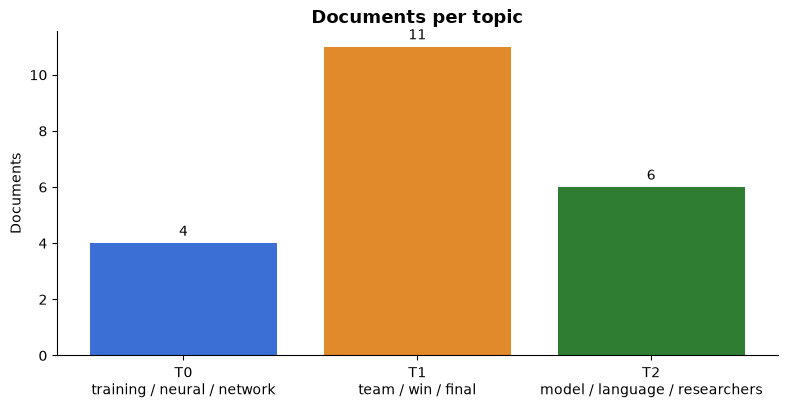

In [4]:
import matplotlib.pyplot as plt

sizes = topic_sizes(model)
labels = [f"T{k}\n{model.topics[k].label}" for k in sizes]
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(labels, list(sizes.values()), color=["#3b6fd6", "#e08a2b", "#2e7d32"][:len(sizes)])
ax.set_title("Documents per topic", fontsize=13, weight="bold")
ax.set_ylabel("Documents")
ax.bar_label(bars, padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("topic_sizes.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Topic | Top words | Theme |
|-------|-----------|-------|
| 0 | training, neural, network, dropout | deep learning |
| 1 | team, win, final, scored, game | sports |
| 2 | model, language, researchers, medical | NLP / models |

Unsupervised topic modeling turns an undifferentiated text pile into labeled, countable themes - the
starting point for tagging tickets, clustering feedback, or mapping a content archive.

**Extend it:** auto-name topics with an LLM, pick the topic count by coherence score, and track topic
prevalence over time to spot emerging issues.

In [5]:
# --- Try your own corpus ---
# docs = ["first document ...", "second document ...", ...]
# m = fit_topics(docs, n_topics=4)
# for t in m.topics: print(t.id, t.top_words)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 114,
Month 12: Data Science Cookbook.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`